In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
df = pd.read_csv("../data/processed/clean_network.csv")
print("Shape:", df.shape)
df.head()


Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,normal,0


In [3]:

if "label" not in df.columns:
    raise ValueError("Dataset must have a 'label' column (0 = normal, 1 = attack)")

X = df.drop(columns=["label"])
y = df["label"].astype(int)

X = pd.get_dummies(X)

print("Feature count:", X.shape[1])


Feature count: 201


In [10]:
X.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,attack_cat_analysis,attack_cat_backdoor,attack_cat_dos,attack_cat_exploits,attack_cat_fuzzers,attack_cat_generic,attack_cat_normal,attack_cat_reconnaissance,attack_cat_shellcode,attack_cat_worms
0,1,0.000011,2,0,496,0,90909.0902,254,0,180363632.0,...,False,False,False,False,False,False,True,False,False,False
1,2,0.000008,2,0,1762,0,125000.0003,254,0,881000000.0,...,False,False,False,False,False,False,True,False,False,False
2,3,0.000005,2,0,1068,0,200000.0051,254,0,854400000.0,...,False,False,False,False,False,False,True,False,False,False
3,4,0.000006,2,0,900,0,166666.6608,254,0,600000000.0,...,False,False,False,False,False,False,True,False,False,False
4,5,0.000010,2,0,2126,0,100000.0025,254,0,850400000.0,...,False,False,False,False,False,False,True,False,False,False


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [11]:
if_model = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination=0.05,  # expected anomaly rate
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_train_scaled)

# Save model for later use
joblib.dump(if_model, "../models/isolation_forest.joblib")
print("Isolation Forest trained and saved.")


Isolation Forest trained and saved.


In [6]:
# Isolation Forest gives negative scores (higher = more normal)
scores = if_model.score_samples(X_test_scaled)
# Convert to positive "anomaly probability": higher = more anomalous
anomaly_prob = (-scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

print("Example scores:", anomaly_prob[:5])


Example scores: [3.40744328 3.54787454 3.48323992 3.70708664 3.43996752]


In [7]:
from sklearn.metrics import precision_recall_fscore_support

best_f1, best_t = 0, 0
for t in np.linspace(0.1, 0.9, 17):
    preds = (anomaly_prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary", zero_division=0)
    if f1 > best_f1:
        best_f1, best_t, best_p, best_r = f1, t, p, r

print(f"Best threshold: {best_t:.2f}")
print(f"Precision: {best_p:.3f} | Recall: {best_r:.3f} | F1: {best_f1:.3f}")


Best threshold: 0.10
Precision: 0.551 | Recall: 1.000 | F1: 0.710


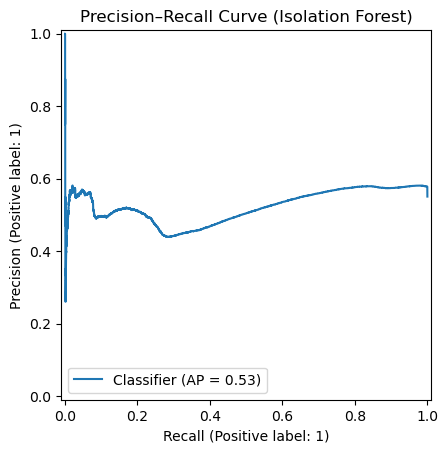

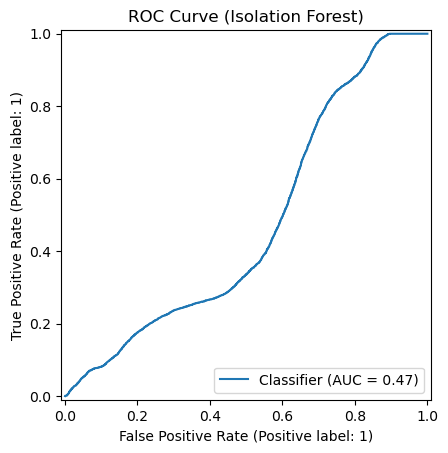

PR-AUC: 0.525
ROC-AUC: 0.474


In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

PrecisionRecallDisplay.from_predictions(y_test, anomaly_prob)
plt.title("Precision–Recall Curve (Isolation Forest)")
plt.show()

RocCurveDisplay.from_predictions(y_test, anomaly_prob)
plt.title("ROC Curve (Isolation Forest)")
plt.show()

# Compute AUCs
prec, rec, _ = precision_recall_curve(y_test, anomaly_prob)
fpr, tpr, _  = roc_curve(y_test, anomaly_prob)
pr_auc  = auc(rec, prec)
roc_auc = auc(fpr, tpr)

print(f"PR-AUC: {pr_auc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")


In [ ]:
out = pd.DataFrame({
    "actual": y_test,
    "anomaly_score": anomaly_prob
})
out.to_csv("../data/processed/if_predictions.csv", index=False)
print("Predictions saved at data/processed/if_predictions.csv")


✅ Predictions saved at data/processed/if_predictions.csv
